# Verify, demonstrate, and preliminarily analyze M2

This notebook validates role-specific perceived-disruption agreement, demonstrates the generated tables and figures, and provides a descriptive preliminary reading for RQ1. It does not interpret agreement as objective extinction risk or telemetry.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import plotly.express as px
from IPython.display import Image, display
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'paper_v9').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from paper_v9.scripts.metrics.m2_role_perception import ROLE_ORDER
METRICS = ROOT / 'paper_v9' / 'data' / 'metrics'
FIGURES = ROOT / 'paper_v9' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

In [2]:
distributions = pd.read_csv(METRICS / 'm2_role_perception_distributions.csv')
summary = pd.read_csv(METRICS / 'm2_role_perception_by_team_semester.csv')
paired = pd.read_csv(METRICS / 'm2_role_perception_paired_t1_t3.csv')
assert set(distributions['role']) == set(ROLE_ORDER)
assert set(summary['role']) == set(ROLE_ORDER)
assert distributions['score'].between(1, 5).all()
assert distributions['share'].between(0, 1).all()
assert summary[['mean', 'std', 'median', 'q1', 'q3', 'iqr']].notna().all().all()
assert summary['iqr'].ge(0).all()
assert paired['pairs'].gt(0).all()
print('schema, role coverage, ranges, distributions, and pairing: PASS')

schema, role coverage, ranges, distributions, and pairing: PASS


In [4]:
v8 = pd.read_csv(ROOT / 'paper_v8' / 'data' / 'm2_role_disruption_risk.csv', dtype={'Semestre': str})
summary['Semestre'] = summary['Semestre'].astype(str)
v8['Semestre'] = v8['Semestre'].astype(str)
comparison = summary.merge(v8[['Semestre', 'temporal_marker', 'role', 'mean', 'median', 'iqr']], on=['Semestre', 'temporal_marker', 'role'], suffixes=('_v9', '_v8'), validate='one_to_one')
assert len(comparison) == len(v8) == 36
assert (comparison['mean_v9'] - comparison['mean_v8']).abs().max() < 1e-12
assert (comparison['median_v9'] - comparison['median_v8']).abs().max() < 1e-12
assert (comparison['iqr_v9'] - comparison['iqr_v8']).abs().max() < 1e-12
comparison[['Semestre', 'temporal_marker', 'role', 'mean_v9', 'mean_v8']].head(12)


,Semestre,temporal_marker,role,mean_v9,mean_v8
0,2025.2,T1,Backend,2.391304,2.391304
1,2025.2,T1,Frontend,2.739130,2.739130
2,2025.2,T1,Product Manager,2.086957,2.086957
3,2025.2,T1,Project Manager,1.826087,1.826087
4,2025.2,T1,QA,2.065217,2.065217
5,2025.2,T1,Scrum Master,2.326087,2.326087
6,2025.2,T2,Backend,2.268293,2.268293
7,2025.2,T2,Frontend,2.682927,2.682927
8,2025.2,T2,Product Manager,1.975610,1.975610
9,2025.2,T2,Project Manager,1.829268,1.829268


/home/amg/projects/uece/Do-We-Still-Need-to-Be-Agile/.venv/lib/python3.11/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



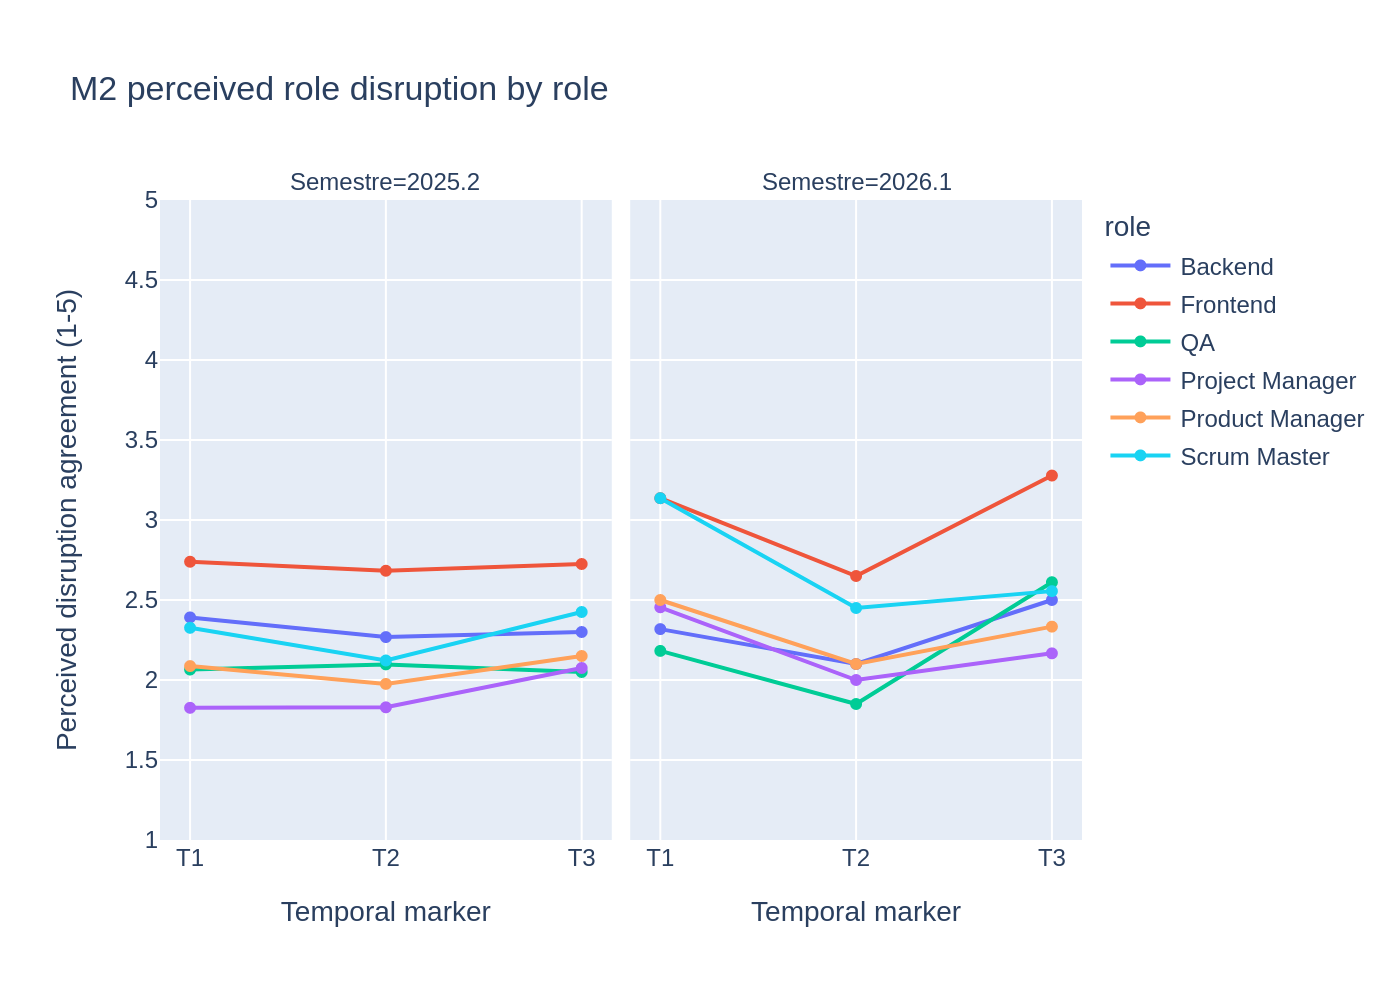

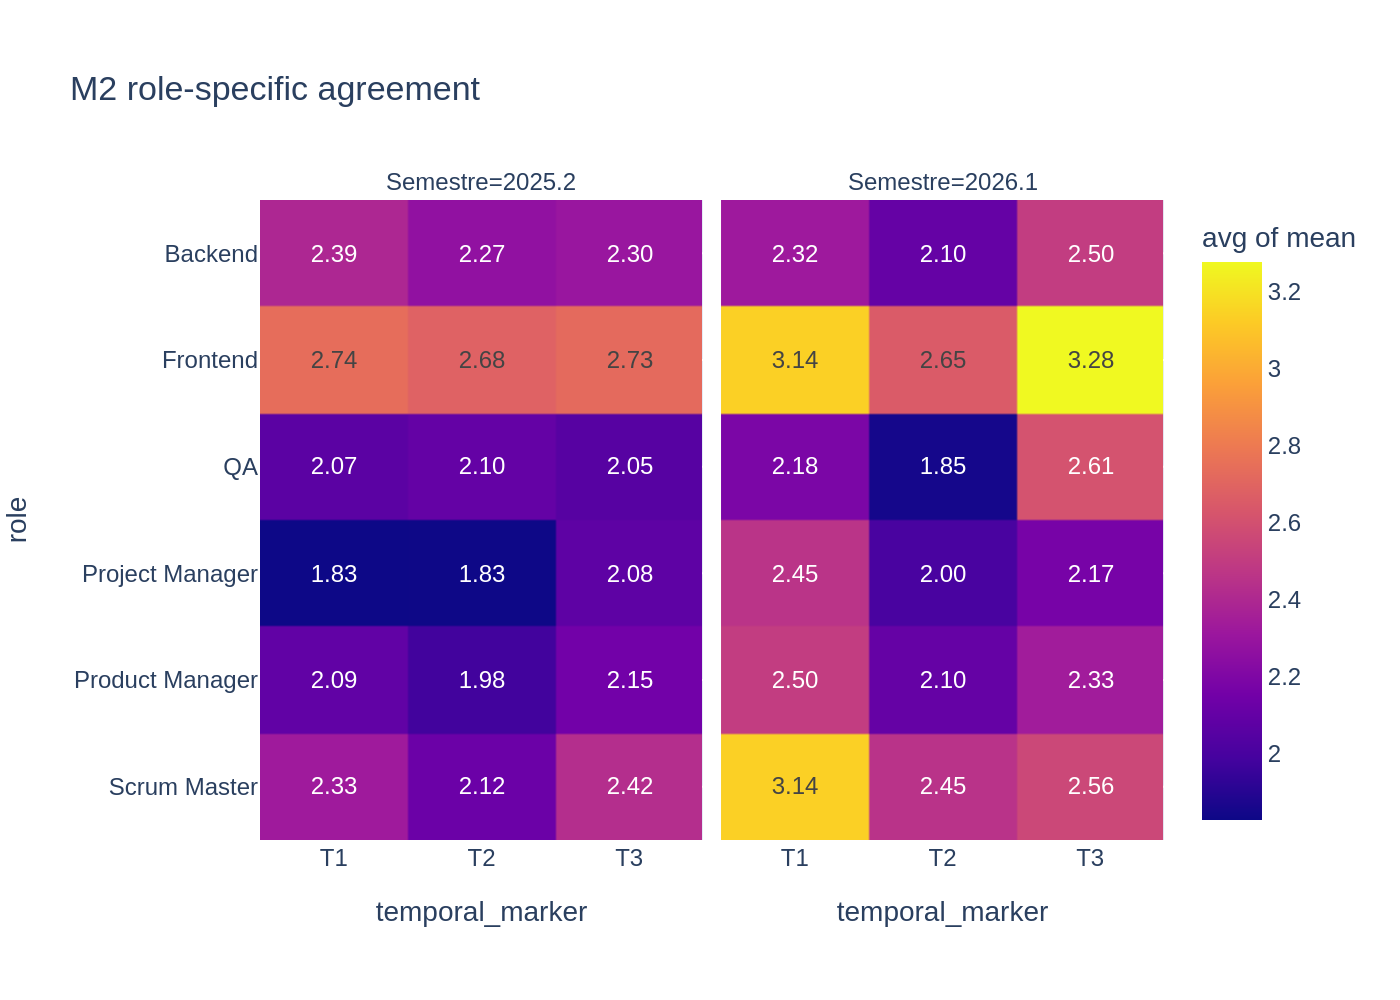

,Semestre,temporal_marker,role,mean,median,iqr,agreement_share
0,2025.2,T1,Backend,2.391304,2.0,1.0,0.108696
1,2025.2,T1,Frontend,2.739130,3.0,1.0,0.239130
2,2025.2,T1,Product Manager,2.086957,2.0,2.0,0.065217
3,2025.2,T1,Project Manager,1.826087,1.5,1.0,0.065217
4,2025.2,T1,QA,2.065217,2.0,1.0,0.108696
5,2025.2,T1,Scrum Master,2.326087,2.0,1.0,0.108696
6,2025.2,T2,Backend,2.268293,2.0,1.0,0.073171
7,2025.2,T2,Frontend,2.682927,3.0,2.0,0.268293
8,2025.2,T2,Product Manager,1.975610,2.0,2.0,0.073171
9,2025.2,T2,Project Manager,1.829268,2.0,1.0,0.024390


artifact demo: M2 tables and article-ready figures displayed


In [5]:
trajectory = px.line(summary, x='temporal_marker', y='mean', color='role', facet_col='Semestre', markers=True, category_orders={'temporal_marker': ['T1', 'T2', 'T3'], 'role': list(ROLE_ORDER)}, labels={'mean': 'Perceived disruption agreement (1-5)', 'temporal_marker': 'Temporal marker'}, title='M2 perceived role disruption by role')
trajectory.update_yaxes(range=[1, 5])
heatmap = px.density_heatmap(summary, x='temporal_marker', y='role', z='mean', histfunc='avg', facet_col='Semestre', category_orders={'temporal_marker': ['T1', 'T2', 'T3'], 'role': list(ROLE_ORDER)}, text_auto='.2f', title='M2 role-specific agreement')
for figure, stem in ((trajectory, 'm2_role_perception_trajectory'), (heatmap, 'm2_role_perception_heatmap')):
    figure.write_html(METRICS / f'{stem}.html', include_plotlyjs='cdn')
    for extension in ('pdf', 'svg', 'png'):
        figure.write_image(FIGURES / f'{stem}.{extension}', scale=2 if extension == 'png' else 1)
for stem in ('m2_role_perception_trajectory', 'm2_role_perception_heatmap'):
    for extension in ('pdf', 'svg', 'png'):
        path = FIGURES / f'{stem}.{extension}'
        assert path.is_file() and path.stat().st_size > 0
    display(Image(filename=str(FIGURES / f'{stem}.png'), width=900))
display(summary[['Semestre', 'temporal_marker', 'role', 'mean', 'median', 'iqr', 'agreement_share']].head(12))
print('artifact demo: M2 tables and article-ready figures displayed')

In [6]:
t1_t3 = summary[summary['temporal_marker'].isin(['T1', 'T3'])].pivot(index=['Semestre', 'role'], columns='temporal_marker', values='mean').reset_index()
t1_t3['descriptive_change_T3_minus_T1'] = t1_t3['T3'] - t1_t3['T1']
assert t1_t3[['T1', 'T3', 'descriptive_change_T3_minus_T1']].notna().all().all()
display(t1_t3.sort_values('descriptive_change_T3_minus_T1', ascending=False).head(12))
metadata = pd.read_json(METRICS / 'm2_role_perception.metadata.json', typ='series')
assert metadata['status'] == 'success'
assert metadata['interpretation'] == 'perceived role disruption agreement, not objective extinction risk'
print('preliminary RQ1 reading: M2 compares perceived role disruption across roles; it does not measure actual adoption or objective job risk')

temporal_marker,Semestre,role,T1,T3,descriptive_change_T3_minus_T1
10,2026.1,QA,2.181818,2.611111,0.429293
3,2025.2,Project Manager,1.826087,2.075000,0.248913
6,2026.1,Backend,2.318182,2.500000,0.181818
7,2026.1,Frontend,3.136364,3.277778,0.141414
5,2025.2,Scrum Master,2.326087,2.425000,0.098913
2,2025.2,Product Manager,2.086957,2.150000,0.063043
1,2025.2,Frontend,2.739130,2.725000,-0.014130
4,2025.2,QA,2.065217,2.050000,-0.015217
0,2025.2,Backend,2.391304,2.300000,-0.091304
8,2026.1,Product Manager,2.500000,2.333333,-0.166667


preliminary RQ1 reading: M2 compares perceived role disruption across roles; it does not measure actual adoption or objective job risk
